# Lab Report 2

## Julian Bermudez-Ortega (2126339)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()

# Loading X (features) and y (targets) for training the model
X_train = iris['data']
y_train = iris['target']

# Names of the features and targets
feature_names = iris['feature_names']
names = iris['target_names']

In [3]:
# I am unable to use the GPU on my laptop
torch.cuda.is_available()

False

In [4]:
# Showing the first 10 samples for the features and targets
print(X_train[:10, :], y_train[:10])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]] [0 0 0 0 0 0 0 0 0 0]


In [5]:
# Showing the shape of the X and y samples
print(X_train.shape, y_train.shape)

(150, 4) (150,)


In [6]:
# Showing the feature names and names
print(feature_names, names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] ['setosa' 'versicolor' 'virginica']


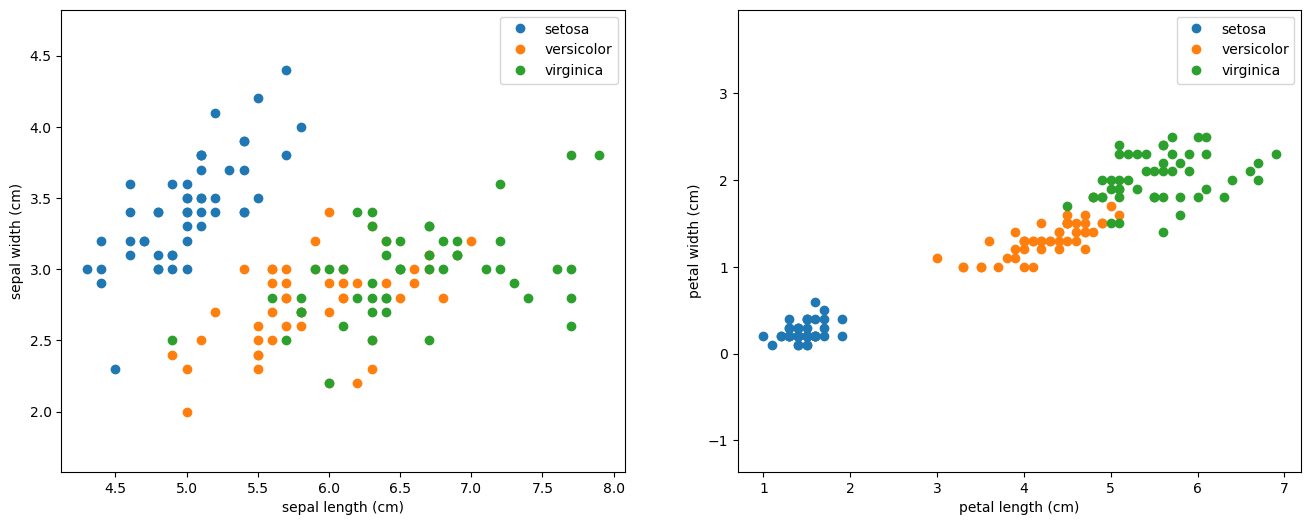

In [7]:
# Plotting the data given before training

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 6))

# Associating values with the different irises
for target, target_name in enumerate(names):

    X_plot = X_train[y_train == target]

    ax1.plot(X_plot[:, 0], X_plot[:, 1], linestyle = 'none', marker = 'o', label = target_name)

ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])
ax1.axis('equal')
ax1.legend()

# Petal length compared to the petal width
for target, target_name in enumerate(names):

    X_plot = X_train[y_train == target]

    ax2.plot(X_plot[:, 2], X_plot[:, 3], linestyle = 'none', marker = 'o', label = target_name)

ax2.set_xlabel(feature_names[2])
ax2.set_ylabel(feature_names[3])
ax2.axis('equal')
ax2.legend()

# Defining the Model

In [8]:
# Creating model

class irisClassification(torch.nn.Module):

    def __init__(self, input_dim, output_dim, hidden_dim):

        super(irisClassification, self).__init__()

        self.layer1 = torch.nn.Linear(input_dim, hidden_dim)
        self.activation = torch.nn.ReLU()
        self.layer2 = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out = self.layer1(x)
        out = self.activation(out)
        out = self.layer2(out)
        return out

# Defining the Hyperparameters

In [9]:
# Defining the dimensions
input_dim = 4
hidden_dim = 350
output_dim = 150

# Defining the irisClassification model to just model
model = irisClassification(input_dim, output_dim, hidden_dim)

# Declaring the learning rate and epochs
learning_rate = 0.05
epochs = 50

# Choosing the loss function and optimizer
loss_func = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

In [10]:
# Starting list that keeps track of the loss
train_loss_list = []

# Training the Model

In [11]:
# Training the model

X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()

for epoch in range(epochs):
    optimizer.zero_grad()

    outputs = model(X_train)

    loss = loss_func(outputs, y_train)

    train_loss_list.append(loss.item())

    loss.backward()

    optimizer.step()

    print('epoch {}, loss {}'.format(epoch, loss.item()))

epoch 0, loss 2.9121975898742676
epoch 1, loss 0.1846483051776886
epoch 2, loss 0.08360777050256729
epoch 3, loss 0.07735512405633926
epoch 4, loss 0.07481493055820465
epoch 5, loss 0.07250101119279861
epoch 6, loss 0.07028040289878845
epoch 7, loss 0.06814474612474442
epoch 8, loss 0.06609046459197998
epoch 9, loss 0.0641142949461937
epoch 10, loss 0.062213096767663956
epoch 11, loss 0.06038396432995796
epoch 12, loss 0.05862400680780411
epoch 13, loss 0.0569305457174778
epoch 14, loss 0.05530091002583504
epoch 15, loss 0.05373267084360123
epoch 16, loss 0.052223384380340576
epoch 17, loss 0.05077076703310013
epoch 18, loss 0.04937267303466797
epoch 19, loss 0.04802700877189636
epoch 20, loss 0.046731818467378616
epoch 21, loss 0.04548511654138565
epoch 22, loss 0.04428505897521973
epoch 23, loss 0.043129853904247284
epoch 24, loss 0.04201781749725342
epoch 25, loss 0.04094729572534561
epoch 26, loss 0.039916716516017914
epoch 27, loss 0.03892456740140915
epoch 28, loss 0.037969417870

C:\Python\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([150])) that is different to the input size (torch.Size([150, 150])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


# Showing the Perfomance

Text(0, 0.5, 'Loss')

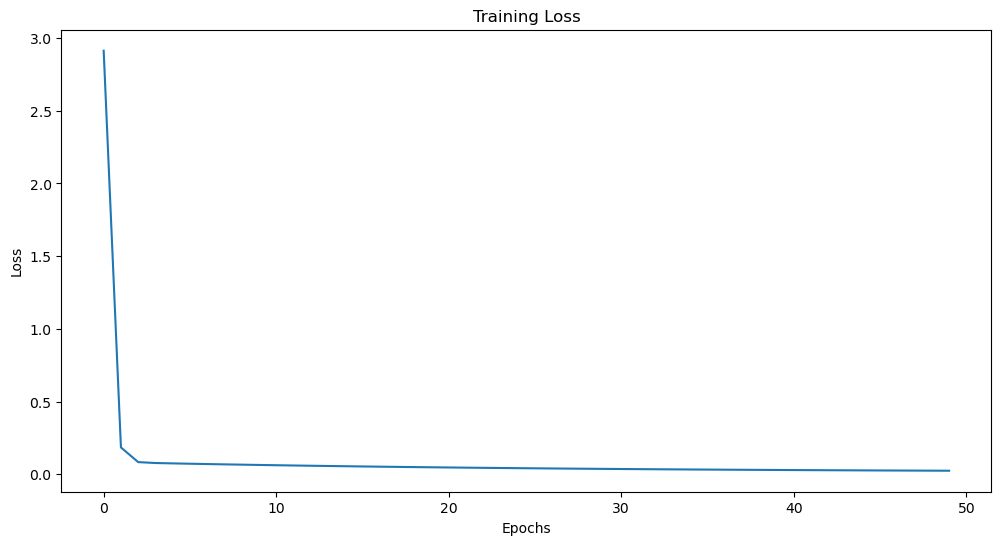

In [12]:
# Plotting the loss found in the training and predictions

plt.figure(figsize = (12, 6))

plt.plot(range(epochs), train_loss_list)
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')



# Accuracy

In [13]:
with torch.no_grad():
    predictions = model(X_train).numpy()
# Rounding the predicions

prediction_labels = np.round(predictions)

# Convert the labels from targets
true_data = y_train.numpy()

# Calculating the training accuracy
training_accuracy = np.mean(prediction_labels == true_data)

print("Training Accuracy:", training_accuracy)


[[-0. -0. -0. ...  2.  2.  2.]
 [-0. -0. -0. ...  2.  2.  2.]
 [-0. -0. -0. ...  2.  2.  2.]
 ...
 [ 0.  0.  0. ...  2.  2.  2.]
 [ 0.  0. -0. ...  2.  2.  2.]
 [ 0.  0. -0. ...  2.  2.  2.]]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2.]
Training Accuracy: 0.9916444444444444
